# Kraus Instances, Setup-Time Formulation Results, 10.4.2026

Comparison of OptalCP vs IBM CPO on all 100 Kraus JSON instances using the setup-time (no_overlap + transition matrix) formulation. Also compared against Kraus's own results (cumulative, cluster1.5, cluster2.5 formulations with IBM CPO).

Setup-time formulace výrazně překonává Krausovy výsledky — na 60 instancích, kde máme oboje, jsme lepší v 57 z 60 případů (průměrně o 17.5 %, medián 20.6 %). Kraus je lepší jen u 3 instancí (gauss s velkým počtem zdrojů, kde je jeho cluster formulace těsnější).

CPO je na setup-times robustnější než OptalCP — CPO vyřešilo 60/100 instancí, OptalCP jen 42/100. OptalCP selhává hlavně na větších instancích (500+ tasků) — nedokáže najít feasible řešení v 180s. Kde oba najdou řešení, jsou výsledky srovnatelné (CPO mírně lepší u skupinových instancí).

Limit škálovatelnosti je ~1000 tasků — od 2000 tasků výš oba solvery dostaly timeout už při stavbě modelu (270s nestačí). Kraus tyto instance řeší svou cluster heuristikou, která model zmenšuje.

Kde oba solvery našly řešení, CPO dává většinou lepší (nižší) objektivy než OptalCP — CPO vyhrává zhruba ve 2/3 případů, typicky o jednotky procent. OptalCP je lepší jen občas, hlavně u menších instancí se 100 tasky.

Best solution time (kdy solver našel své nejlepší řešení) se ale liší zásadně: CPO typicky najde své nejlepší řešení velmi rychle, často do 1–10s, někdy už za 0.06s. OptalCP potřebuje výrazně déle — best solution time bývá 50–170s, často až ke konci limitu. To znamená, že CPO rychle najde dobré řešení a pak ho jen mírně vylepšuje, zatímco OptalCP dlouho hledá první feasible řešení a pak zlepšuje postupně.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('.')
KRAUS_CSV = Path('../../kraus-diplomka/rcpsptt_docplex_solver-master/data/results.csv')

# Load our results
with open(RESULTS_DIR / 'optal_setup.json') as f:
    optal_raw = json.load(f)
with open(RESULTS_DIR / 'cpo_setup.json') as f:
    cpo_raw = json.load(f)

optal = pd.DataFrame(optal_raw)
cpo = pd.DataFrame(cpo_raw)

print(f'OptalCP: {len(optal)} instances')
print(f'CPO:     {len(cpo)} instances')

OptalCP: 100 instances
CPO:     100 instances


## 1. Overview: Solve Status

In [2]:
status_optal = optal['state'].value_counts()
status_cpo = cpo['state'].value_counts()

status_df = pd.DataFrame({'OptalCP': status_optal, 'CPO': status_cpo}).fillna(0).astype(int)
print('=== Solve Status ===')
print(status_df)
print()

print(f'OptalCP feasible rate: {(optal["state"].isin(["Feasible", "Optimal"])).sum()}/{len(optal)}')
print(f'CPO feasible rate:     {(cpo["state"].isin(["Feasible", "Optimal"])).sum()}/{len(cpo)}')

=== Solve Status ===
            OptalCP  CPO
state                   
Feasible         42   60
NoSolution       18    0
Timeout          40   40

OptalCP feasible rate: 42/100
CPO feasible rate:     60/100


## 2. Objective Comparison: OptalCP vs CPO

In [3]:
# Merge on instance name
merged = optal[['instance', 'objective', 'state', 'duration', 'build_time', 'best_solution_time', 'n_jobs', 'n_resources']].merge(
    cpo[['instance', 'objective', 'state', 'duration', 'build_time', 'best_solution_time']],
    on='instance', suffixes=('_optal', '_cpo')
)

# Both solved
both_solved = merged[
    merged['objective_optal'].notna() & merged['objective_cpo'].notna()
].copy()

print(f'Both solvers found a solution: {len(both_solved)}/{len(merged)} instances')
print()

if len(both_solved) > 0:
    both_solved['optal_better'] = both_solved['objective_optal'] < both_solved['objective_cpo']
    both_solved['cpo_better'] = both_solved['objective_cpo'] < both_solved['objective_optal']
    both_solved['equal'] = both_solved['objective_optal'] == both_solved['objective_cpo']
    both_solved['gap_pct'] = 100 * (both_solved['objective_cpo'] - both_solved['objective_optal']) / both_solved['objective_cpo']

    print(f'OptalCP better: {both_solved["optal_better"].sum()}')
    print(f'CPO better:     {both_solved["cpo_better"].sum()}')
    print(f'Equal:          {both_solved["equal"].sum()}')
    print(f'\nAvg gap (CPO-OptalCP)/CPO: {both_solved["gap_pct"].mean():.2f}%')
    print(f'Median gap: {both_solved["gap_pct"].median():.2f}%')

Both solvers found a solution: 42/100 instances

OptalCP better: 14
CPO better:     28
Equal:          0

Avg gap (CPO-OptalCP)/CPO: -1.65%
Median gap: -1.35%


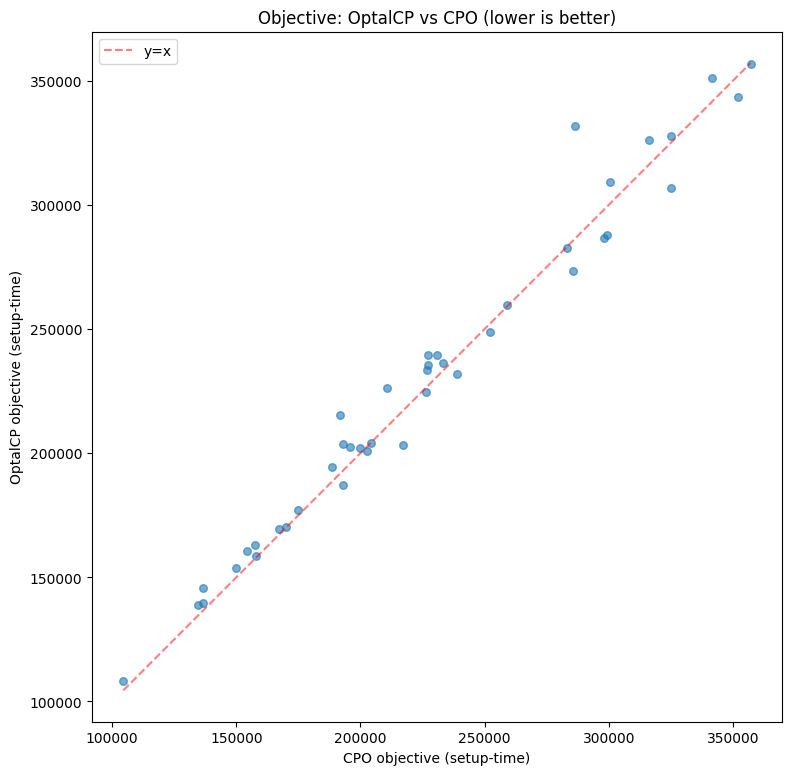

In [4]:
# Scatter plot: OptalCP vs CPO objectives
if len(both_solved) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(both_solved['objective_cpo'], both_solved['objective_optal'], alpha=0.6, s=30)
    lims = [min(both_solved[['objective_cpo', 'objective_optal']].min()),
            max(both_solved[['objective_cpo', 'objective_optal']].max())]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
    ax.set_xlabel('CPO objective (setup-time)')
    ax.set_ylabel('OptalCP objective (setup-time)')
    ax.set_title('Objective: OptalCP vs CPO (lower is better)')
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## 3. Runtime Comparison

In [5]:
# Build time comparison
print('=== Build Time (model construction) ===')
for label, df in [('OptalCP', optal), ('CPO', cpo)]:
    bt = df['build_time'].dropna()
    print(f'  {label}: mean={bt.mean():.2f}s, median={bt.median():.2f}s, max={bt.max():.2f}s')

print()
print('=== Solve Duration (wall time) ===')
for label, df in [('OptalCP', optal), ('CPO', cpo)]:
    dur = df['duration'].dropna()
    print(f'  {label}: mean={dur.mean():.2f}s, median={dur.median():.2f}s, max={dur.max():.2f}s')

print()
print('=== Best Solution Time ===')
for label, df in [('OptalCP', optal), ('CPO', cpo)]:
    bst = df['best_solution_time'].dropna()
    if len(bst) > 0:
        print(f'  {label}: mean={bst.mean():.2f}s, median={bst.median():.2f}s, max={bst.max():.2f}s')

=== Build Time (model construction) ===
  OptalCP: mean=0.12s, median=0.04s, max=0.44s
  CPO: mean=0.11s, median=0.06s, max=0.64s

=== Solve Duration (wall time) ===
  OptalCP: mean=216.05s, median=180.15s, max=270.00s
  CPO: mean=216.16s, median=180.41s, max=270.00s

=== Best Solution Time ===
  OptalCP: mean=126.42s, median=144.03s, max=179.37s
  CPO: mean=0.06s, median=0.05s, max=0.14s


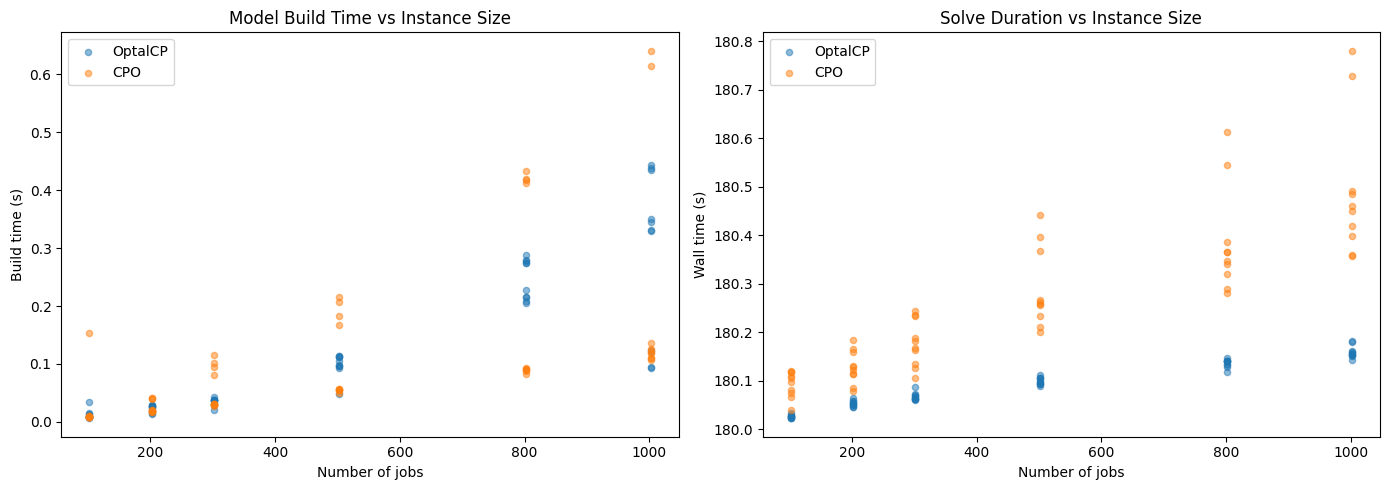

In [6]:
# Build time by instance size
if 'n_jobs' in merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(merged['n_jobs'], merged['build_time_optal'], alpha=0.5, label='OptalCP', s=20)
    ax.scatter(merged['n_jobs'], merged['build_time_cpo'], alpha=0.5, label='CPO', s=20)
    ax.set_xlabel('Number of jobs')
    ax.set_ylabel('Build time (s)')
    ax.set_title('Model Build Time vs Instance Size')
    ax.legend()

    ax = axes[1]
    ax.scatter(merged['n_jobs'], merged['duration_optal'], alpha=0.5, label='OptalCP', s=20)
    ax.scatter(merged['n_jobs'], merged['duration_cpo'], alpha=0.5, label='CPO', s=20)
    ax.set_xlabel('Number of jobs')
    ax.set_ylabel('Wall time (s)')
    ax.set_title('Solve Duration vs Instance Size')
    ax.legend()

    plt.tight_layout()
    plt.show()

## 4. Results by Instance Size

Kraus instances are named like `NNNN_type_tasks_resources[_groups].json`.
Parse the task count to group results.

In [7]:
import re

def parse_instance_info(name):
    """Extract tasks, resources from instance name like 0001_random_100_5."""
    parts = name.split('_')
    # Pattern: NNNN_type_tasks_resources[_groups]
    tasks = int(parts[2]) if len(parts) >= 3 else None
    resources = int(parts[3]) if len(parts) >= 4 else None
    itype = parts[1] if len(parts) >= 2 else None
    return tasks, resources, itype

merged['tasks'], merged['resources'], merged['type'] = zip(*merged['instance'].apply(parse_instance_info))

# Group by task count
for n_tasks in sorted(merged['tasks'].unique()):
    subset = merged[merged['tasks'] == n_tasks]
    n = len(subset)
    optal_solved = subset['objective_optal'].notna().sum()
    cpo_solved = subset['objective_cpo'].notna().sum()
    
    both = subset[subset['objective_optal'].notna() & subset['objective_cpo'].notna()]
    optal_wins = (both['objective_optal'] < both['objective_cpo']).sum() if len(both) > 0 else 0
    cpo_wins = (both['objective_cpo'] < both['objective_optal']).sum() if len(both) > 0 else 0
    
    print(f'Tasks={n_tasks:>5} ({n:>2} inst): '
          f'OptalCP solved {optal_solved}/{n}, CPO solved {cpo_solved}/{n} | '
          f'OptalCP better: {optal_wins}, CPO better: {cpo_wins}')

Tasks=  100 (10 inst): OptalCP solved 10/10, CPO solved 10/10 | OptalCP better: 2, CPO better: 8
Tasks=  200 (10 inst): OptalCP solved 10/10, CPO solved 10/10 | OptalCP better: 3, CPO better: 7
Tasks=  300 (10 inst): OptalCP solved 10/10, CPO solved 10/10 | OptalCP better: 2, CPO better: 8
Tasks=  500 (10 inst): OptalCP solved 7/10, CPO solved 10/10 | OptalCP better: 4, CPO better: 3
Tasks=  800 (10 inst): OptalCP solved 4/10, CPO solved 10/10 | OptalCP better: 3, CPO better: 1
Tasks= 1000 (10 inst): OptalCP solved 1/10, CPO solved 10/10 | OptalCP better: 0, CPO better: 1
Tasks= 2000 (10 inst): OptalCP solved 0/10, CPO solved 0/10 | OptalCP better: 0, CPO better: 0
Tasks= 3000 (10 inst): OptalCP solved 0/10, CPO solved 0/10 | OptalCP better: 0, CPO better: 0
Tasks= 5000 (10 inst): OptalCP solved 0/10, CPO solved 0/10 | OptalCP better: 0, CPO better: 0
Tasks= 7000 (10 inst): OptalCP solved 0/10, CPO solved 0/10 | OptalCP better: 0, CPO better: 0


## 5. Comparison with Kraus's Results

Kraus used IBM CPO with three formulations:
- **cumul**: standard cumulative formulation
- **cluster1.5**: clustering with factor 1.5
- **cluster2.5**: clustering with factor 2.5

We compare our setup-time results against his best result per instance.

In [8]:
# Load Kraus results
kraus = pd.read_csv(KRAUS_CSV)
kraus['instance'] = kraus['file'].str.replace('.json', '', regex=False)
kraus['kraus_best'] = kraus[['cumul', 'cluster1.5', 'cluster2.5']].min(axis=1)
kraus['kraus_best_method'] = kraus[['cumul', 'cluster1.5', 'cluster2.5']].idxmin(axis=1)

print(f'Kraus results: {len(kraus)} instances')
print(f'Best method distribution:')
print(kraus['kraus_best_method'].value_counts())
print()
kraus[['instance', 'cumul', 'cluster1.5', 'cluster2.5', 'kraus_best']].head(10)

Kraus results: 90 instances
Best method distribution:
kraus_best_method
cluster2.5    40
cluster1.5    37
cumul         13
Name: count, dtype: int64



,instance,cumul,cluster1.5,cluster2.5,kraus_best
0,0001_random_100_5,336130,332685,319779,319779
1,0002_gauss_100_5,225860,218888,219253,218888
2,0003_group_100_5_5,312310,328799,325040,312310
3,0004_group_100_5_10,299864,308950,300765,299864
4,0005_group_100_5_20,344937,347935,349020,344937
5,0006_random_100_10,181198,180859,180026,180026
6,0007_gauss_100_10,116888,112676,113465,112676
7,0008_group_100_10_5,226426,192021,215313,192021
8,0009_group_100_10_10,210211,206942,198698,198698
9,0010_group_100_10_20,210137,199472,195517,195517


In [9]:
# Merge our results with Kraus
compare = merged.merge(kraus[['instance', 'cumul', 'cluster1.5', 'cluster2.5', 'kraus_best']], on='instance', how='outer')

# Our best = min(optal, cpo) where available
compare['our_best'] = compare[['objective_optal', 'objective_cpo']].min(axis=1)
compare['our_best_solver'] = compare.apply(
    lambda r: 'optal' if pd.notna(r['objective_optal']) and (pd.isna(r['objective_cpo']) or r['objective_optal'] <= r['objective_cpo'])
              else ('cpo' if pd.notna(r['objective_cpo']) else None), axis=1)

# Compare where both have results
both_have = compare[compare['our_best'].notna() & compare['kraus_best'].notna()].copy()
print(f'Instances with both our and Kraus results: {len(both_have)}')
print()

if len(both_have) > 0:
    both_have['we_better'] = both_have['our_best'] < both_have['kraus_best']
    both_have['kraus_better'] = both_have['kraus_best'] < both_have['our_best']
    both_have['equal'] = both_have['our_best'] == both_have['kraus_best']
    both_have['gap_pct'] = 100 * (both_have['our_best'] - both_have['kraus_best']) / both_have['kraus_best']

    print(f'Our setup-time better:  {both_have["we_better"].sum()}')
    print(f'Kraus better:           {both_have["kraus_better"].sum()}')
    print(f'Equal:                  {both_have["equal"].sum()}')
    print(f'\nAvg gap (ours-kraus)/kraus: {both_have["gap_pct"].mean():.2f}%')
    print(f'Median gap: {both_have["gap_pct"].median():.2f}%')
    print(f'  (positive = we are worse, negative = we are better)')

Instances with both our and Kraus results: 60

Our setup-time better:  57
Kraus better:           3
Equal:                  0

Avg gap (ours-kraus)/kraus: -17.48%
Median gap: -20.62%
  (positive = we are worse, negative = we are better)


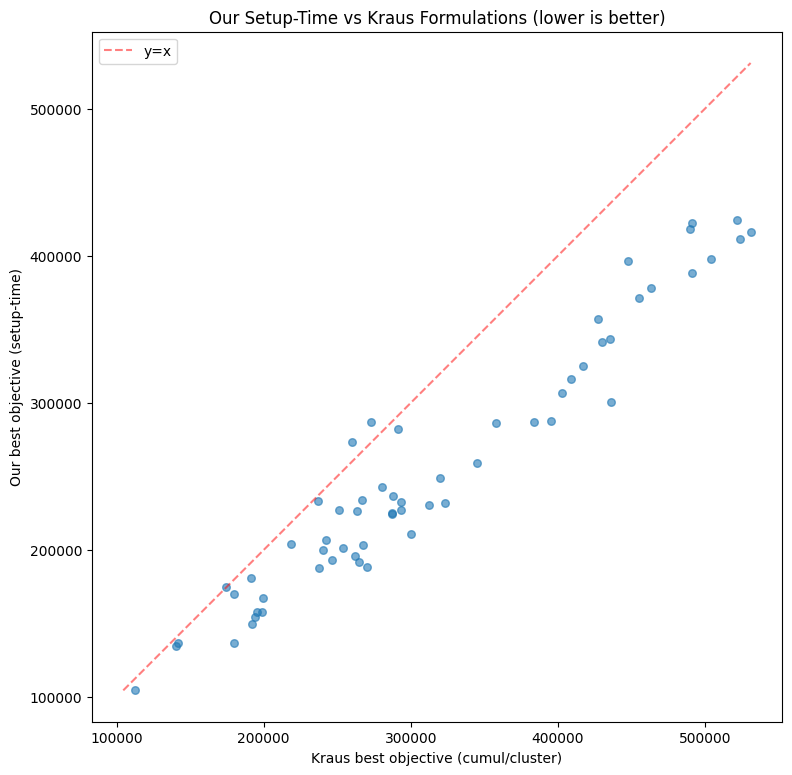

In [10]:
# Scatter: our best vs Kraus best
if len(both_have) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(both_have['kraus_best'], both_have['our_best'], alpha=0.6, s=30)
    lims = [min(both_have[['kraus_best', 'our_best']].min()),
            max(both_have[['kraus_best', 'our_best']].max())]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
    ax.set_xlabel('Kraus best objective (cumul/cluster)')
    ax.set_ylabel('Our best objective (setup-time)')
    ax.set_title('Our Setup-Time vs Kraus Formulations (lower is better)')
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

=== Gap (%) by instance size (positive = we are worse) ===
        mean  median  count
tasks                      
100   -20.30  -22.08     10
200   -19.77  -21.89     10
300   -19.75  -21.26     10
500   -15.05  -16.63     10
800   -15.67  -20.80     10
1000  -14.32  -16.23     10



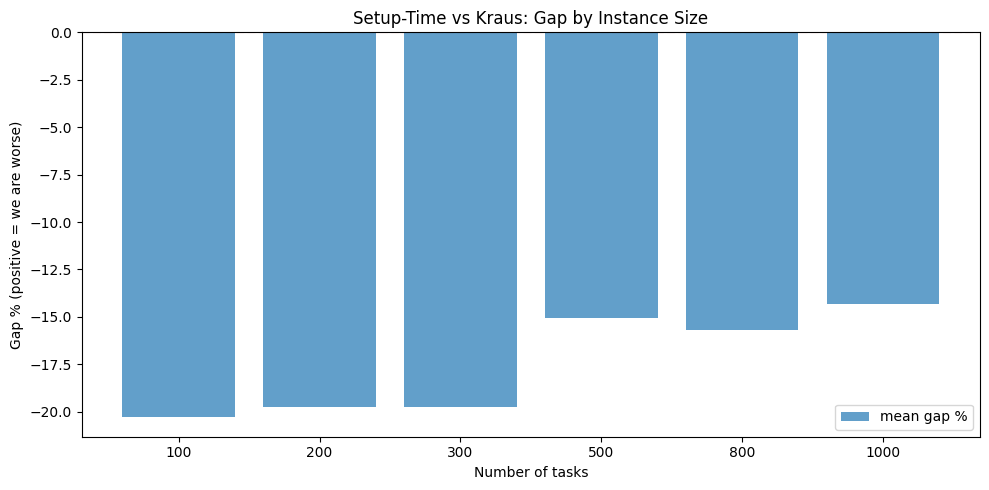

In [11]:
# Gap by instance size
if len(both_have) > 0:
    both_have['tasks'], both_have['resources'], both_have['type'] = zip(
        *both_have['instance'].apply(parse_instance_info))

    gap_by_size = both_have.groupby('tasks')['gap_pct'].agg(['mean', 'median', 'count'])
    print('=== Gap (%) by instance size (positive = we are worse) ===')
    print(gap_by_size.round(2))
    print()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(gap_by_size.index.astype(str), gap_by_size['mean'], alpha=0.7, label='mean gap %')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of tasks')
    ax.set_ylabel('Gap % (positive = we are worse)')
    ax.set_title('Setup-Time vs Kraus: Gap by Instance Size')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Detailed Results Table

In [12]:
# Full comparison table
table = compare[['instance', 'n_jobs', 'n_resources',
                 'objective_optal', 'state_optal', 'duration_optal', 'build_time_optal',
                 'objective_cpo', 'state_cpo', 'duration_cpo', 'build_time_cpo',
                 'kraus_best']].copy()

table.columns = ['Instance', 'Jobs', 'Res',
                 'OptalCP Obj', 'OptalCP State', 'OptalCP Time', 'OptalCP Build',
                 'CPO Obj', 'CPO State', 'CPO Time', 'CPO Build',
                 'Kraus Best']

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 200)
table

,Instance,Jobs,Res,OptalCP Obj,OptalCP State,OptalCP Time,OptalCP Build,CPO Obj,CPO State,CPO Time,CPO Build,Kraus Best
0,0001_random_100_5,102.0,5.0,248973.0,Feasible,180.027,0.035,252079.0,Feasible,180.040,0.154,319779.0
1,0002_gauss_100_5,102.0,5.0,203997.0,Feasible,180.026,0.013,204380.0,Feasible,180.106,0.008,218888.0
2,0003_group_100_5_5,102.0,5.0,239588.0,Feasible,180.026,0.008,230765.0,Feasible,180.110,0.008,312310.0
3,0004_group_100_5_10,102.0,5.0,226452.0,Feasible,180.033,0.012,210578.0,Feasible,180.118,0.010,299864.0
4,0005_group_100_5_20,102.0,5.0,259533.0,Feasible,180.027,0.009,259182.0,Feasible,180.066,0.009,344937.0
5,0006_random_100_10,102.0,10.0,145826.0,Feasible,180.023,0.008,136700.0,Feasible,180.097,0.009,180026.0
6,0007_gauss_100_10,102.0,10.0,108352.0,Feasible,180.024,0.008,104472.0,Feasible,180.082,0.009,112676.0
7,0008_group_100_10_5,102.0,10.0,153894.0,Feasible,180.023,0.006,149737.0,Feasible,180.076,0.008,192021.0
8,0009_group_100_10_10,102.0,10.0,162940.0,Feasible,180.027,0.009,157611.0,Feasible,180.120,0.010,198698.0
9,0010_group_100_10_20,102.0,10.0,158601.0,Feasible,180.030,0.015,157833.0,Feasible,180.119,0.009,195517.0
